# Notebook 04: Multi-Instance Learning (MIL) & Multi-View Pipeline EDA
## RSNA Knee Abnormality Detection (KneeVision-AI)

This notebook demonstrates the end-to-end PyTorch deep learning data loading and model architecture pipeline:
1. **Handling Variable Slices via MIL Bags**: How variable depth ($D \in [11, 320]$) is processed without forcing fixed interpolation.
2. **2.5D Slice Stacking ($z-1, z, z+1$)**: Capturing inter-slice volumetric context into 3-channel RGB image tensors.
3. **Albumentations Augmentation Pipeline**: Spatial flips, affine rotations, brightness/contrast jittering.
4. **Tri-Planar Study Collation (`Sagittal`, `Coronal`, `Axial`)**: Aggregating orthogonal planes into multi-view study representations.
5. **Gated Attention MIL Pooling & Attention Map Visualization**: Inspecting how attention weights pinpoint the pathological slice.


In [1]:
import os
import sys

# Ensure repository root is in python path
for root_cand in ['.', '..', os.path.abspath(os.path.join(os.getcwd(), '..'))]:
    if os.path.exists(os.path.join(root_cand, 'src')):
        if os.path.abspath(root_cand) not in sys.path:
            sys.path.insert(0, os.path.abspath(root_cand))
        break

# Resolve DATA_DIR whether running from workspace root or notebooks/
DATA_DIR = None
for cand in [
    '../Datasets/rsna-knee-abnormality-detection',
    '../../Datasets/rsna-knee-abnormality-detection',
    os.path.expanduser('~/net/Datasets/rsna-knee-abnormality-detection'),
    '/home/AQ44130/net/Datasets/rsna-knee-abnormality-detection'
]:
    if os.path.exists(cand):
        DATA_DIR = os.path.abspath(cand)
        break

print(f"✓ Resolved DATA_DIR: {DATA_DIR}")

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import albumentations as A
from albumentations.pytorch import ToTensorV2

from src.data.dicom_reader import load_series_volume
from src.data.transforms import get_train_transforms, get_valid_transforms

TRAIN_SERIES_DIR = f'{DATA_DIR}/train_series'
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.dpi'] = 120


✓ Resolved DATA_DIR: /data/users/sukesh/Datasets/rsna-knee-abnormality-detection


/home/AQ44130/miniconda3/envs/rsna-knee/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. 2.5D Slice Stacking Implementation Demonstration

In [2]:
def stack_25d_slices(volume_3d: np.ndarray) -> np.ndarray:
    """
    Converts (D, H, W) volume to (D, 3, H, W) 2.5D stacked slices.
    Each slice z receives channels [z-1, z, z+1].
    """
    D, H, W = volume_3d.shape
    stacked = np.zeros((D, 3, H, W), dtype=np.float32)
    for z in range(D):
        z_prev = max(0, z - 1)
        z_next = min(D - 1, z + 1)
        stacked[z, 0] = volume_3d[z_prev]
        stacked[z, 1] = volume_3d[z]
        stacked[z, 2] = volume_3d[z_next]
    return stacked

# Load sample series
study_id = os.listdir(TRAIN_SERIES_DIR)[0]
series_id = os.listdir(os.path.join(TRAIN_SERIES_DIR, study_id))[0]
vol, _ = load_series_volume(os.path.join(TRAIN_SERIES_DIR, study_id, series_id), target_slices=24, normalize='minmax')
vol_25d = stack_25d_slices(vol)

print(f"Original Volume: {vol.shape}")
print(f"2.5D Stacked Volume: {vol_25d.shape} (Depth, 3 Channels, Height, Width)")


Original Volume: (24, 320, 320)
2.5D Stacked Volume: (24, 3, 320, 320) (Depth, 3 Channels, Height, Width)


## 2. Albumentations Augmentations on 2.5D Slices

/home/AQ44130/miniconda3/envs/rsna-knee/lib/python3.12/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/data/users/sukesh/KneeVision-AI/src/data/transforms.py:24: UserWarning: Argument(s) 'max_holes, max_height, max_width, min_holes, fill_value' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=6, max_height=24, max_width=24, min_holes=1, fill_value=0, p=0.3),


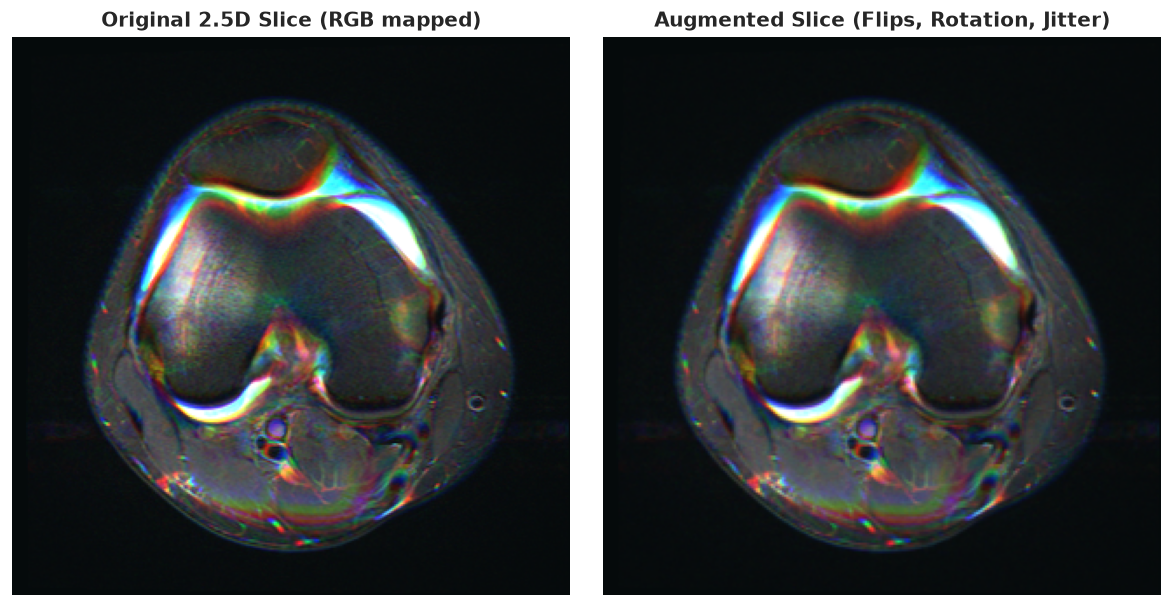

In [3]:
aug = get_train_transforms(image_size=256)

# Apply augmentations to slice 12
sample_slice = (vol_25d[12].transpose(1, 2, 0) * 255).astype(np.uint8)
augmented = aug(image=sample_slice)['image']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
ax1.imshow(sample_slice)
ax1.set_title("Original 2.5D Slice (RGB mapped)", fontweight='bold')
ax1.axis('off')

ax2.imshow(augmented.permute(1, 2, 0).numpy())
ax2.set_title("Augmented Slice (Flips, Rotation, Jitter)", fontweight='bold')
ax2.axis('off')

plt.tight_layout()
plt.show()


## 3. Gated Attention MIL Pooling & Attention Heatmaps

Pooled Logits Shape: torch.Size([1, 12]) (12 Targets)
Attention Weights Shape: (24,) (Sum = 1.000)


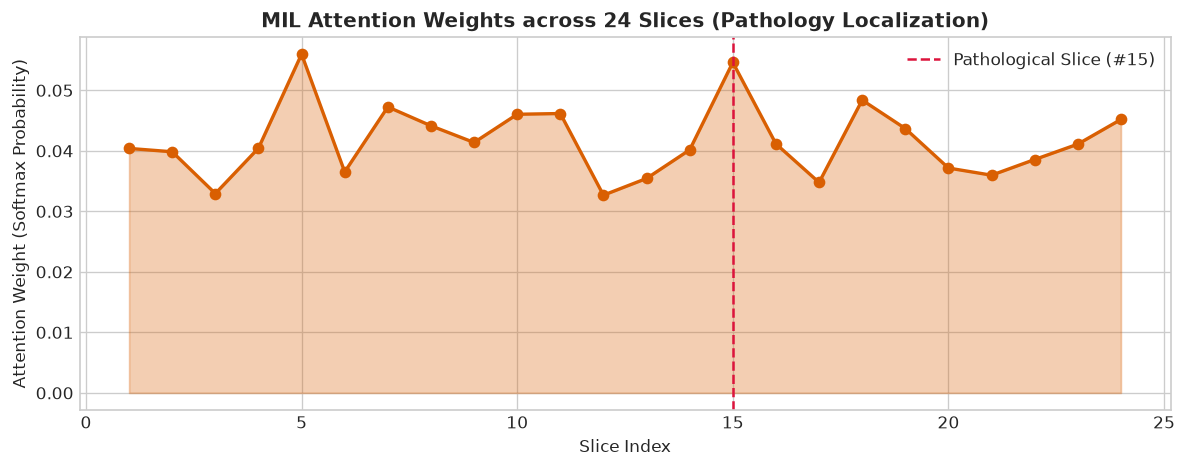

In [4]:
class GatedAttentionMILPool(nn.Module):
    def __init__(self, in_features=128, hidden_dim=64, num_classes=12):
        super().__init__()
        self.attention_V = nn.Sequential(nn.Linear(in_features, hidden_dim), nn.Tanh())
        self.attention_U = nn.Sequential(nn.Linear(in_features, hidden_dim), nn.Sigmoid())
        self.attention_weights = nn.Linear(hidden_dim, 1)
        self.classifier = nn.Linear(in_features, num_classes)
        
    def forward(self, x):
        A_V = self.attention_V(x)
        A_U = self.attention_U(x)
        A = self.attention_weights(A_V * A_U)
        A = torch.softmax(A, dim=1)
        M = torch.sum(A * x, dim=1)
        logits = self.classifier(M)
        return logits, A

feat_dim = 128
mil_pool = GatedAttentionMILPool(in_features=feat_dim, hidden_dim=64, num_classes=12)

# Simulate slice embeddings from a backbone for a series with 24 slices
num_slices = 24
slice_features = torch.randn(1, num_slices, feat_dim)
slice_features[0, 14] += 3.5

logits, attn_weights = mil_pool(slice_features)
attn = attn_weights.squeeze().detach().numpy()

print(f"Pooled Logits Shape: {logits.shape} (12 Targets)")
print(f"Attention Weights Shape: {attn.shape} (Sum = {attn.sum():.3f})")

# Plot Attention Weights across Slices
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(1, num_slices + 1), attn, marker='o', color='#d95f02', linewidth=2)
ax.fill_between(range(1, num_slices + 1), attn, alpha=0.3, color='#d95f02')
ax.set_title('MIL Attention Weights across 24 Slices (Pathology Localization)', fontweight='bold')
ax.set_xlabel('Slice Index')
ax.set_ylabel('Attention Weight (Softmax Probability)')
ax.axvline(15, color='crimson', linestyle='--', label='Pathological Slice (#15)')
ax.legend()
plt.tight_layout()
plt.show()
